## Inputation and integration for two batch simulation

### Inputation

In [1]:
import scanpy as sc
import torch as th
import scanpy as sc
import pandas as pd
import torch.nn as nn
import sys
sys.path.append(r"/data/xiangdw/MODEL/")
from SpaMIE.create_graph import Sagegraph
from SpaMIE.spamie_main import Sagewrapper
device = th.device('cuda:0' if th.cuda.is_available() else 'cpu')
file_fold = '/data/xiangdw/data/data/' 
from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "font.size":12,
    "axes.unicode_minus": False #解决负号无法显示的问题
}
rcParams.update(config)

/home/xiangdw/.conda/envs/SpaMIE/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import datetime
file_fold = '/data/xiangdw/data/data/Simu_2batch_invert/'
a = []
layers_nums = 3
for i in range(1):
    starttime = datetime.datetime.now()
    seeds = i+1
    adata_omics1 = sc.read_h5ad(file_fold + str(seeds) + 'simu_mod2_concat.h5ad')
    adata_omics2 = sc.read_h5ad(file_fold + str(seeds) + 'simu_mod1_concat.h5ad')

    modalities = [adata_omics1, adata_omics2]
    g_spatial_omics1, g_feature_omics1, adata_omics1, adata_omics2 = Sagegraph(modalities, device, datatype='simu', batch=True)
    output_dir = '/data/xiangdw/data/pred result/'
    weight = [0,0,1]

    pred_name = 'simu_SpaMIE_'+str(layers_nums)+'_pred.csv'
    true_name = 'simu_SpaMIE_'+str(layers_nums)+'_truth.csv'

    in_feat = adata_omics1.obsm['feat'].shape[1]
    out_feat = adata_omics2.X.shape[1]

    model = Sagewrapper(seed=(int(seeds)), device=device, in_feat=in_feat, n_hidden=256, out_feat=out_feat, task='prediction', datatype='simu',
                        layers_nums=int(layers_nums), weight=weight, epoch=600, res_type='res_add', activation=nn.LeakyReLU
                        , sagetype='mean', lr=2e-4, lr2 = 0.002)

    adata_omics1_pred, adata_omics2_pred, test_idx, train_idx,wt,alph  = model.fit(adata_omics1, adata_omics2, g_spatial_omics1, g_feature_omics1, 
                                                                                    output_dir=output_dir, pred_name=pred_name, 
                                                                                    true_name=true_name, weight=True, save_csv=False)



2026-05-28 13:01:26,476 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-28 13:01:28,259 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-28 13:01:28,276 - harmonypy - INFO - Iteration 1 of 10
2026-05-28 13:01:28,696 - harmonypy - INFO - Iteration 2 of 10
2026-05-28 13:01:28,931 - harmonypy - INFO - Iteration 3 of 10
2026-05-28 13:01:29,279 - harmonypy - INFO - Iteration 4 of 10
2026-05-28 13:01:29,623 - harmonypy - INFO - Iteration 5 of 10
2026-05-28 13:01:29,864 - harmonypy - INFO - Converged after 5 iterations
/data/xiangdw/MODEL/SpaMIE/spamie_net.py:98: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.alpha = F.softmax(torch.squeeze(self.vu) + 1e-6)


Early stopped.


### Integration

In [2]:
import os
import dgl
import pandas as pd
os.getcwd()
os.chdir('/data/xiangdw/MODEL/')
print(os.getcwd())
import sys
import scanpy as sc
import importlib 
import torch as th
import torch.nn as nn
from sklearn.utils import shuffle

from matplotlib import rcParams

config = {
    "font.family":'Times New Roman', 
     "font.size":20, # 设置字体类型
    "axes.unicode_minus": False #解决负号无法显示的问题
}
rcParams.update(config)

/data/xiangdw/MODEL


In [4]:
import torch.nn.functional as F
from SpaMIE.create_graph import Sagegraph
from SpaMIE.spamie_main import Sagewrapper
import numpy as np
from model_integration import set_seed
device = th.device('cuda:1' if th.cuda.is_available() else 'cpu')


for i in range(1): 
    seeds = str(i+1)
    path = '/data/xiangdw/data/data/Simu_2batch_invert/'
    adata_omics1 = sc.read_h5ad(path + str(seeds) + 'simu_mod2_concat.h5ad')
    adata_omics2 = sc.read_h5ad(path + str(seeds) + 'simu_mod1_concat.h5ad')

    test_idx = '/data/xiangdw/data/pred result/sage pred result/'+seeds+'_simu_2batch_invert_test_idx.csv'
    y_pred_name = '/data/xiangdw/data/pred result/SpaMIE pred result/'+seeds+'simu_SpaMIE_new_res3_wt_pred_2batch_invert_50.csv'
    modalities = [adata_omics1, adata_omics2]
    g_spatial_omics1, g_feature_omics1, g_spatial_omics2,g_feature_omics2, adata_omics1, adata_omics2 = Sagegraph(modalities, device, task="Integration", test_idx_name=test_idx,
                                                                                                                   y_pred_name=y_pred_name, pred_joint=False, datatype="simu",batch=True)

    in_feat = adata_omics1.obsm['feat'].shape[1]
    out_feat = adata_omics2.X.shape[1]
    weight = [1,1,1]
    model = Sagewrapper(seed=(int(seeds)), device=device, in_feat=in_feat, n_hidden=256, out_feat=out_feat, task='integration', datatype='simu',
                        layers_nums=int(3), weight=weight, epoch=600, res_type='res_add', activation=nn.LeakyReLU
                        , sagetype='mean', lr=2e-4, lr2 = 0.002)

    output  = model.fit( adata_omics1, adata_omics2, g_spatial_omics1, g_feature_omics1, g_spatial_omics2, g_feature_omics2,weight_factors=[1,5,1,1])

    adata_omics2.obsm['SpaMIE'] = output[0].detach().cpu().numpy()
    

2026-05-28 13:19:50,033 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-28 13:19:51,834 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-28 13:19:51,851 - harmonypy - INFO - Iteration 1 of 10
2026-05-28 13:19:52,222 - harmonypy - INFO - Iteration 2 of 10
2026-05-28 13:19:52,597 - harmonypy - INFO - Iteration 3 of 10
2026-05-28 13:19:52,961 - harmonypy - INFO - Converged after 3 iterations
2026-05-28 13:19:52,983 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-28 13:19:54,667 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-28 13:19:54,678 - harmonypy - INFO - Iteration 1 of 10
2026-05-28 13:19:55,118 - harmonypy - INFO - Iteration 2 of 10
2026-05-28 13:19:55,526 - harmonypy - INFO - Iteration 3 of 10
2026-05-28 13:19:55,837 - harmonypy - INFO - Converged after 3 iterations
/data/xiangdw/MODEL/SpaMIE/spamie_net.py:98: UserWarning: Implicit dimension choice for softmax has been depreca

Searching resolution...
resolution=0.24009999999999998, cluster number=6
resolution=0.2301, cluster number=5


/data/xiangdw/conda_env/GNNS/lib/python3.8/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/data/xiangdw/conda_env/GNNS/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/xiangdw/conda_env/GNNS/lib/python3.8/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/data/xiangdw/conda_env/GNNS/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


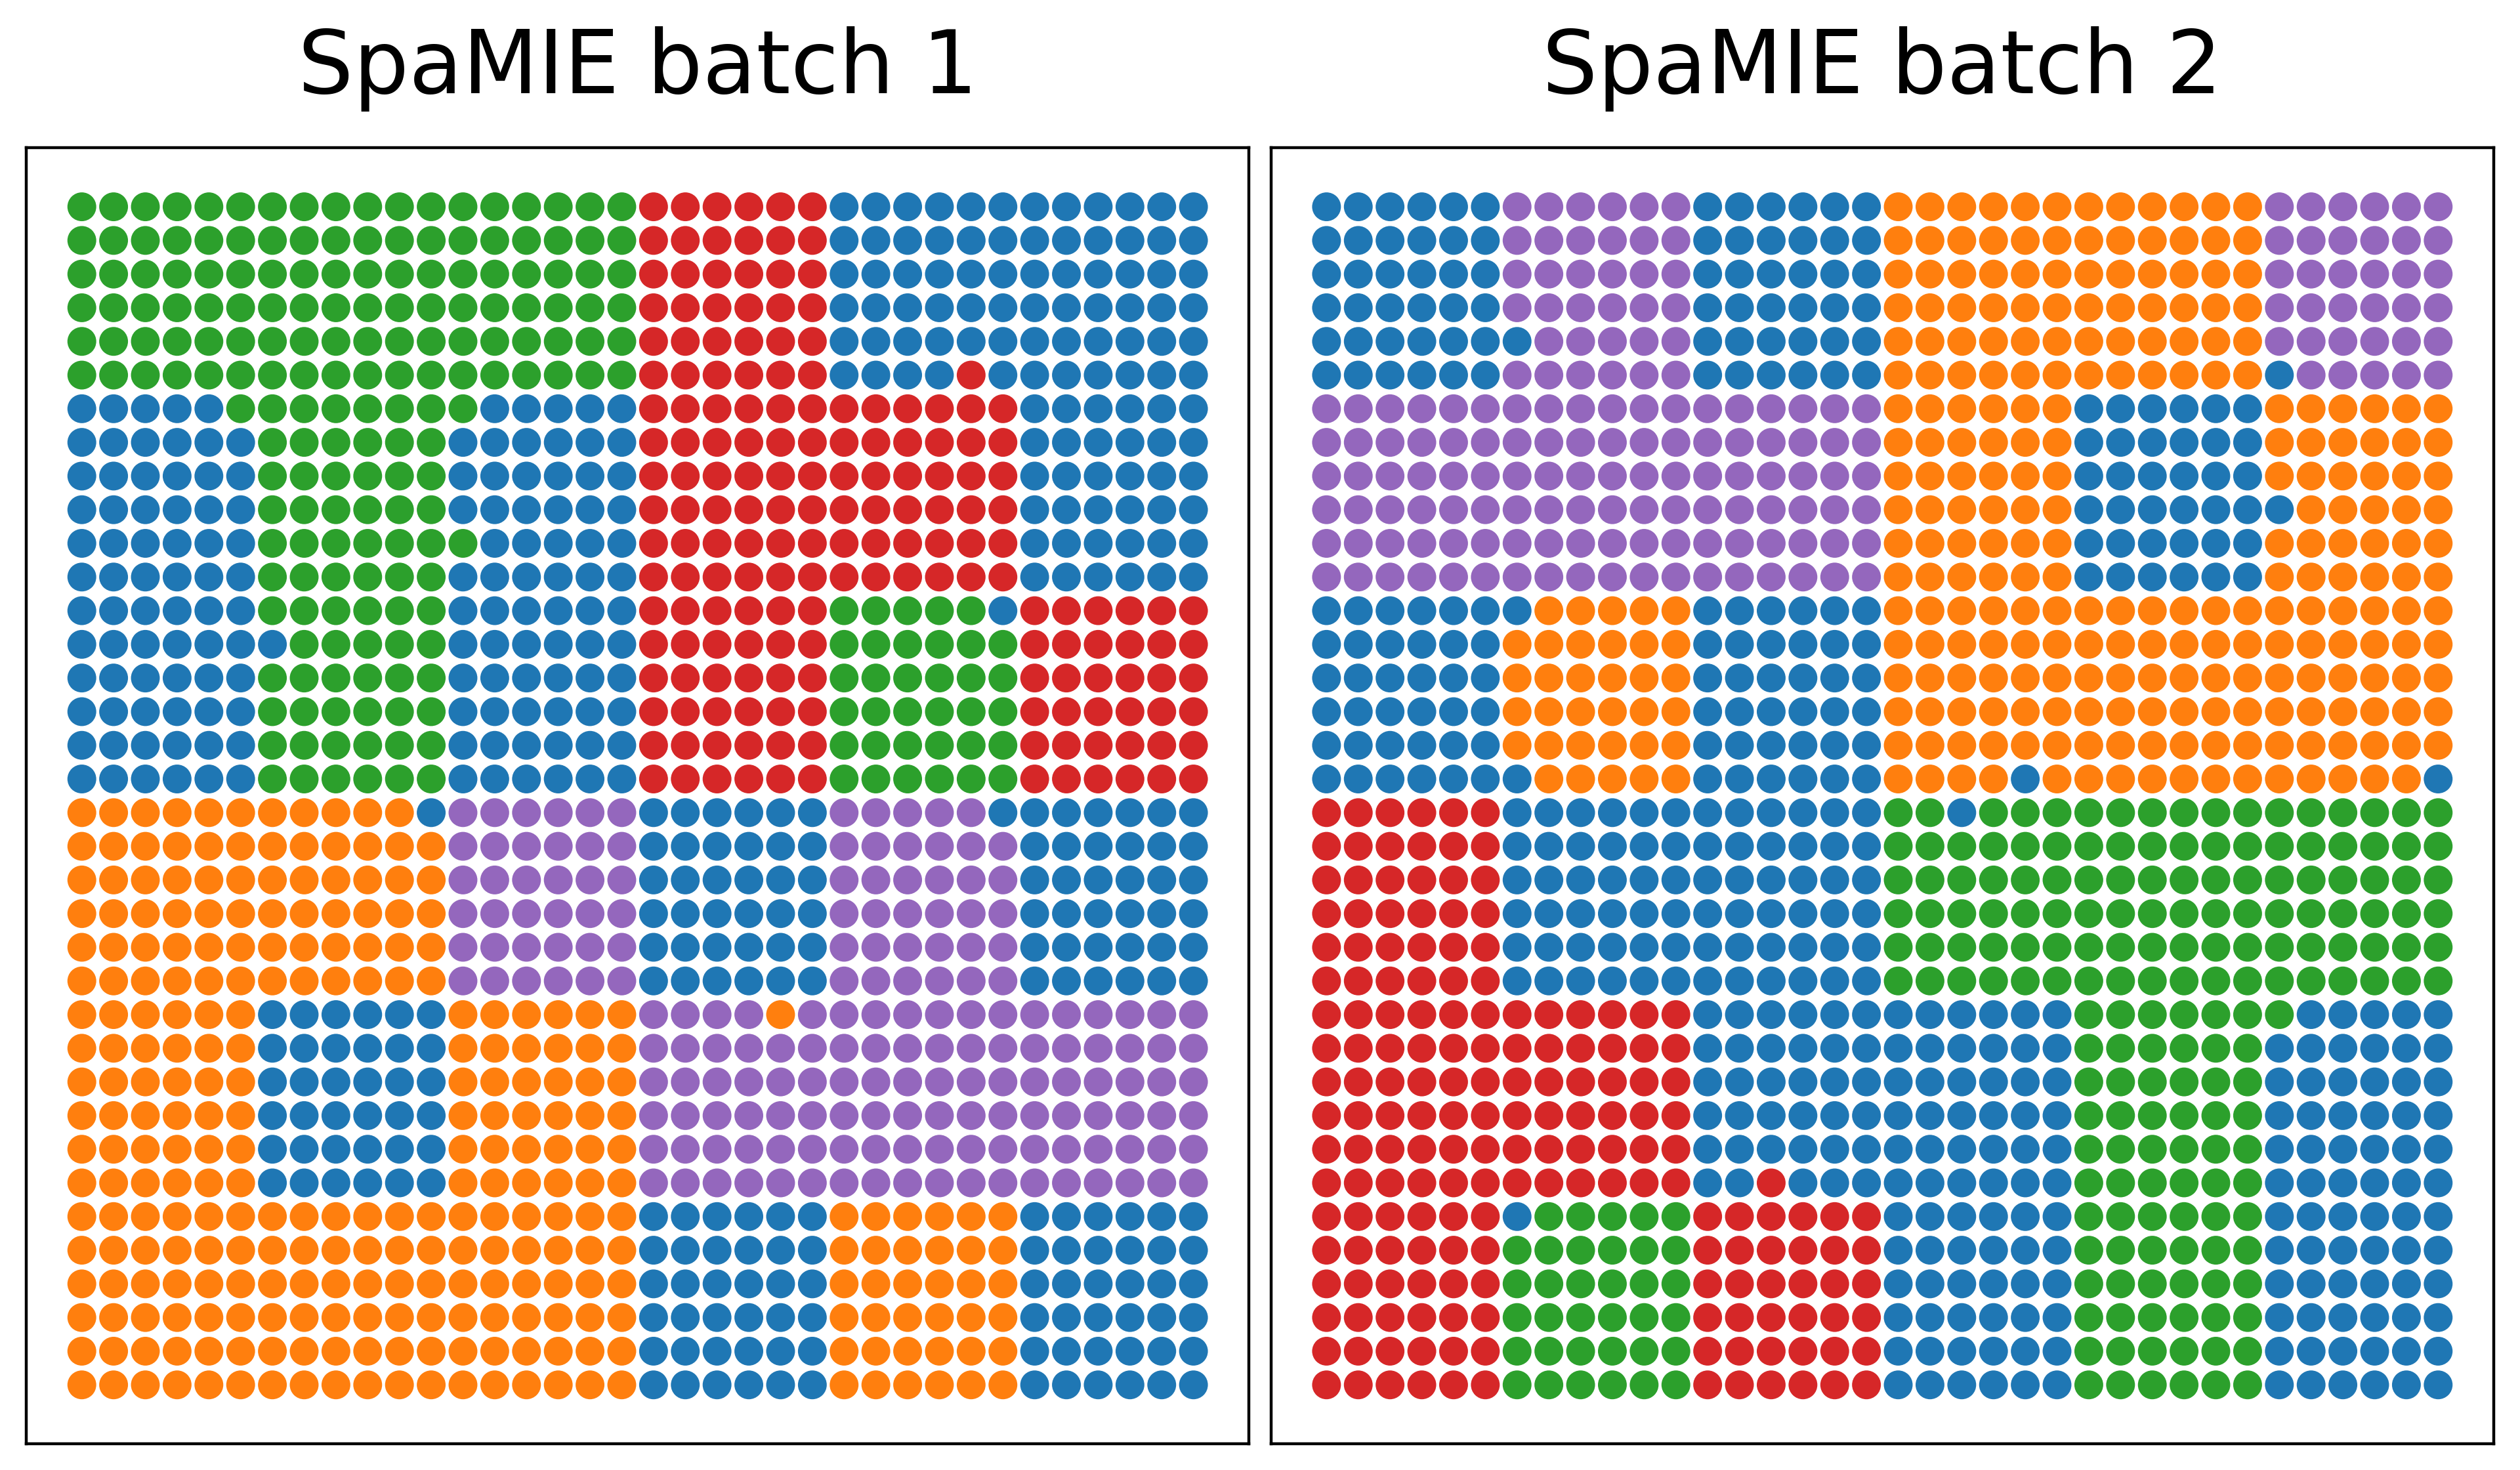

In [ ]:

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
path = '/data/xiangdw/data/data/Simu_2batch_invert/'
adata = adata_omics2
adata1 = adata[adata.obs['batch']=='1']
adata2 = adata[adata.obs['batch']=='2']
from SpatialGlue.utils import clustering
tool = 'louvain' # mclust, leiden, and louvain
clustering(adata, key='SpaMIE', add_key='SpaMIE', start=0.0001, increment=0.01,end=0.25, n_clusters=5,
                    method=tool, use_pca=False)
fig, ax_list = plt.subplots(1, 2, figsize=(10, 6), dpi=400)
plt.rcParams['font.size'] = 20
sc.pl.embedding(adata1, basis='spatial', color=['SpaMIE'], ax=ax_list[0], title='SpaMIE', s=250, show=False)
sc.pl.embedding(adata2, basis='spatial', color=['SpaMIE'], ax=ax_list[1], title='', s=250, show=False)
ax_list[0].set_title('SpaMIE batch 1', pad=15)
ax_list[1].set_title('SpaMIE batch 2', pad=15)
# remove x, y axis
ax_list[0].set_xlabel('')
ax_list[1].set_xlabel('')
ax_list[0].set_ylabel('')
ax_list[1].set_ylabel('')
ax_list[0].get_legend().remove()
ax_list[1].get_legend().remove()

plt.tight_layout(w_pad=.3)
plt.show()
